In [1]:
import pandas as pd
fp = "data/coffee_prices.csv"
df = pd.read_csv(fp)
df.columns = ["date", "cents-per-lb"]
df.date = pd.to_datetime(df.date)

In [2]:
import matplotlib.pyplot as plt
import ruptures as rpt
import numpy as np


In [3]:
from math import ceil, log
penalty_est = ceil(2*log(df.shape[0],2))
signal = df["cents-per-lb"].values

In [4]:
penalty_est

18

In [5]:
# Detect change points using the Pelt algorithm with an 'l2' model (change in mean)
algo = rpt.Pelt(model="rbf").fit(signal)
result = algo.predict(pen=penalty_est) # 'pen' parameter controls the number of changes


In [6]:
# Display the results
result

[210, 375, 426]

In [7]:
def label_segment(row):
    row_idx = row.name
    row_label = None
    index = 1
    for cp in result:
        if row_idx <= cp:
            row_label = "segment-" + str(index)
            break
        else:
            index += 1
    return row_label

df["segment"] = df.apply(label_segment, axis =1)
            

In [8]:
df

,date,cents-per-lb,segment
0,1990-01-01,75.829987,segment-1
1,1990-02-01,84.010010,segment-1
2,1990-03-01,93.959991,segment-1
3,1990-04-01,93.730011,segment-1
4,1990-05-01,92.019989,segment-1
...,...,...,...
421,2025-02-01,409.516500,segment-3
422,2025-03-01,404.210476,segment-3
423,2025-04-01,392.912727,segment-3
424,2025-05-01,397.588636,segment-3


In [9]:
from math import ceil, log

class ChangePointEstimator:
    def __init__(self, series):
        self._df = series.to_frame().reset_index()
        self._df.columns = ["date", "signal"]
        self._change_pts = None
        return

    def label_segement(self, row):
        row_idx = row.name
        row_label = None
        index = 1
        
        for cp in self._change_pts:
            if row_idx <= cp:
                row_label = "segment-" + str(index)
                break
            else:
                index += 1
        
        return row_label
        
    def estimate_change_points(self):
        penalty_est = ceil(2*log(self._df.shape[0],2))
        # Detect change points using the Pelt algorithm with an 'l2' model (change in mean)
        algo = rpt.Pelt(model="rbf").fit(signal)
        self._change_pts = algo.predict(pen=penalty_est) # 'pen' parameter controls the number of changes
        self._df["segment"] = self._df.apply(lambda row: self.label_segement(row), axis=1)

        return
        

In [10]:
price_series = df["cents-per-lb"]
price_series.index = df["date"]

In [11]:
cpe = ChangePointEstimator(price_series)

In [12]:
cpe.estimate_change_points()

In [13]:
cpe._df

,date,signal,segment
0,1990-01-01,75.829987,segment-1
1,1990-02-01,84.010010,segment-1
2,1990-03-01,93.959991,segment-1
3,1990-04-01,93.730011,segment-1
4,1990-05-01,92.019989,segment-1
...,...,...,...
421,2025-02-01,409.516500,segment-3
422,2025-03-01,404.210476,segment-3
423,2025-04-01,392.912727,segment-3
424,2025-05-01,397.588636,segment-3


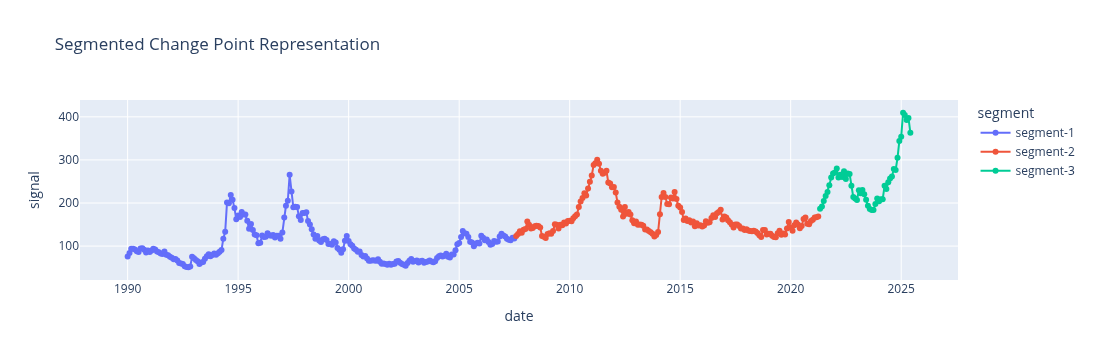

In [14]:
import plotly.express as px
import pandas as pd



# Create the line plot with the 'color' attribute
fig = px.line(
    cpe._df,
    x="date",
    y="signal",
    color="segment",  # This attribute automatically colors lines by country
    title="Segmented Change Point Representation"
)

# Customize the plot appearance (optional)
fig.update_traces(mode='lines+markers') # Add markers to the lines

# Display the figure
fig.show()


In [15]:
from visualization.series_visualizer import SegmentedSeriesVisualizer

In [16]:
ssv = SegmentedSeriesVisualizer(cpe._df)

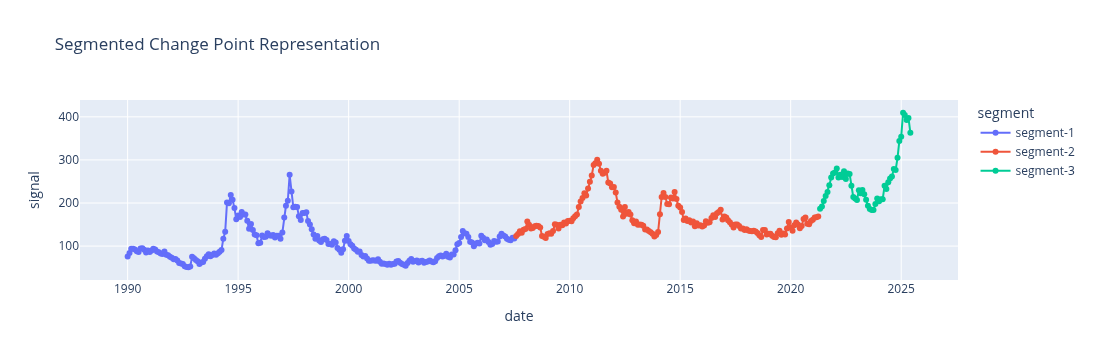

In [17]:
ssv.getVisualization().show()